In [13]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

import figure_utils
from importlib import reload
reload(figure_utils)
from figure_utils import (
    format_model_str_nsynth,
    normalize_model_name,
    marker_palette_for_hue,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    get_model_groups,
    model_label,
    plot_grouped_bars,
)

In [14]:

# outfig_dir = Path('talk_figs/mcdermott_update/figs')
# outfig_dir.mkdir(parents=True, exist_ok=True)


## Get Nsynth results for each model

In [15]:
path_to_nsynth_results = Path("eval_nsynth_results")

all_model_results = list(path_to_nsynth_results.rglob("audioset_*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("resnet18_barlow*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("resnet50_barlow*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("kell2018*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("word_kell2018*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("config_*nsynth*.pkl"))
all_model_results += list(path_to_nsynth_results.rglob("byola*nsynth*.pkl"))
# all_model_results

test_layers = [
                'preproc',
                'batchnorm0',
                'conv0',
                'relu0',
                'maxpool0',
                'batchnorm1',
                'conv1',
                'relu1',
                'maxpool1',
                'batchnorm2',
                'conv2',
                'relu2',
                'conv3',
                'relu3',
                'conv4',
                'relu4',
                'avgpool',
                'fullyconnected',
                'relufc',
                'dropout',
                ]
                
resnet18_layer_order = [
                'preproc',
                'conv1',
                'bn1',
                'relu1',
                'maxpool1',
                'layer1',
                'layer2',
                'layer3',
                'layer4',
                'avgpool',
            ]            
layer_order_dict = {l:i for i,l in enumerate(test_layers)}
df_list = []

for i, results_path in enumerate(all_model_results):
    path_str = str(results_path)

    results = pd.read_pickle(results_path)
    overall_acc = results['top1_mean']

    model_name, arch_class, test_layer, eq_lmbda = format_model_str_nsynth(results_path)
    
    data = dict(model_name=model_name, arch_class=arch_class, test_layer=test_layer, eq_lmbda=eq_lmbda, overall_acc=overall_acc)

    df_list.append(data)

nsynth_df = pd.DataFrame.from_records(df_list)
nsynth_df['test_layer'] = nsynth_df['test_layer'].astype('str')
nsynth_df['model_name'] = nsynth_df['model_name'].apply(normalize_model_name)

nsynth_df = nsynth_df.loc[nsynth_df['test_layer'].map({k: i for i, k in enumerate(test_layers)}) \
                .sort_values().index]

In [16]:
# Check what models are in the dataframe
print("Available model names in dataframe:")
print(nsynth_df.model_name.unique())
print("\nModels with relu4 layer:")
print(nsynth_df[(nsynth_df.test_layer.str.contains('relu4')) & (~nsynth_df.overall_acc.isna())].model_name.unique())
nsynth_df

Available model names in dataframe:
['CochDNN9 supervised audioset' 'CochDNN9 ssl λ=0.4' 'CochDNN9 ssl λ=0.5'
 'CochDNN9 scaled ssl λ=0.5' 'CochDNN9 ssl λ=0.0' 'CochDNN9 ssl λ=0.2'
 'CochDNN9 scaled supervised' 'CochDNN9 scaled ssl λ=0.0'
 'CochDNN9 supervised multi-task' 'CochDNN9 ssl λ=0.3'
 'CochDNN9 ssl λ=0.1' 'CochDNN9 supervised word' 'byol-a']

Models with relu4 layer:
['CochDNN9 supervised audioset' 'CochDNN9 ssl λ=0.4' 'CochDNN9 ssl λ=0.5'
 'CochDNN9 scaled ssl λ=0.5' 'CochDNN9 ssl λ=0.0' 'CochDNN9 ssl λ=0.2'
 'CochDNN9 scaled supervised' 'CochDNN9 scaled ssl λ=0.0'
 'CochDNN9 supervised multi-task' 'CochDNN9 ssl λ=0.3'
 'CochDNN9 ssl λ=0.1' 'CochDNN9 supervised word']


,model_name,arch_class,test_layer,eq_lmbda,overall_acc
0,CochDNN9 supervised audioset,kell2018,relu4,,0.661865
1,CochDNN9 ssl λ=0.4,kell2018,relu4,0.4,0.659424
2,CochDNN9 ssl λ=0.5,kell2018,relu4,0.5,0.636719
3,CochDNN9 scaled ssl λ=0.5,kell2018,relu4,0.5,0.701172
4,CochDNN9 ssl λ=0.0,kell2018,relu4,0.0,0.684326
5,CochDNN9 ssl λ=0.2,kell2018,relu4,0.2,0.683838
6,CochDNN9 scaled supervised,kell2018,relu4,,0.713135
7,CochDNN9 scaled ssl λ=0.0,kell2018,relu4,0.0,0.700195
8,CochDNN9 supervised multi-task,kell2018,relu4,,0.691162
9,CochDNN9 ssl λ=0.3,kell2018,relu4,0.3,0.674072


Normalized hue_order:
['CochDNN9 supervised multi-task', 'CochDNN9 supervised word', 'CochDNN9 supervised audioset', 'CochDNN9 scaled supervised', 'CochDNN9 ssl λ=0.0', 'CochDNN9 ssl λ=0.1', 'CochDNN9 ssl λ=0.2', 'CochDNN9 ssl λ=0.3', 'CochDNN9 ssl λ=0.4', 'CochDNN9 ssl λ=0.5', 'CochDNN9 scaled ssl λ=0.0', 'CochDNN9 scaled ssl λ=0.5', 'CochDNN9 ssl dual λ=0.0', 'CochDNN9 ssl dual λ=0.0 unpaired augs', 'CochDNN9 ssl dual λ=0.01', 'CochDNN9 ssl dual λ=0.1', 'CochDNN9 ssl dual λ=0.5', 'resnet50 ssl λ=0.5', 'resnet50 scaled ssl λ=0.5', 'resnet18 scaled ssl λ=0.0', 'resnet18 scaled ssl λ=0.5', 'byol-a']

Models in nsynth_to_plot: ['CochDNN9 supervised audioset' 'CochDNN9 ssl λ=0.4' 'CochDNN9 ssl λ=0.5'
 'CochDNN9 scaled ssl λ=0.5' 'CochDNN9 ssl λ=0.0' 'CochDNN9 ssl λ=0.2'
 'CochDNN9 scaled supervised' 'CochDNN9 scaled ssl λ=0.0'
 'CochDNN9 supervised multi-task' 'CochDNN9 ssl λ=0.3'
 'CochDNN9 ssl λ=0.1' 'CochDNN9 supervised word' 'byol-a']
Number of rows: 13


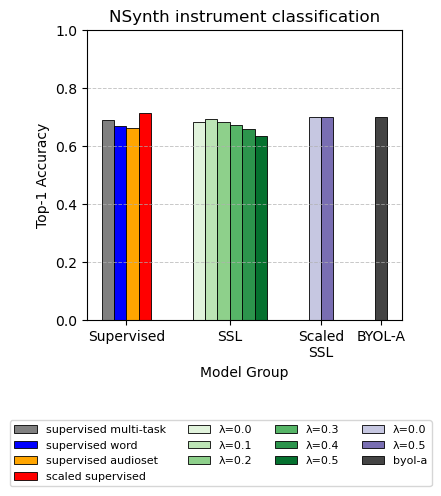

In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import re

# Get standardized hue order and colors
hue_order = get_standard_hue_order()
marker_palette = marker_palette_for_hue(hue_order)
base_colors = get_standard_base_colors()
hue_dict = build_model_palette(hue_order, base_colors)

# Debug: Check normalized hue_order
print("Normalized hue_order:")
print(hue_order)

# Focus on relu4 layer only (as before) - filter after hue_order is normalized
# First get all relu4 data
nsynth_to_plot = nsynth_df[
    ~nsynth_df.overall_acc.isna() & 
    ((nsynth_df.test_layer.str.contains('relu4')) | ((nsynth_df.model_name == 'byol-a') & (nsynth_df.test_layer.str.contains('final'))))
]

# Now filter to only models in hue_order (after normalization)
nsynth_to_plot = nsynth_to_plot[nsynth_to_plot.model_name.isin(hue_order)]

# Debug: Check what models are in the filtered data
print(f"\nModels in nsynth_to_plot: {nsynth_to_plot.model_name.unique()}")
print(f"Number of rows: {len(nsynth_to_plot)}")
if len(nsynth_to_plot) == 0:
    print("WARNING: No data to plot! Check model name matching.")

# Get model groups (for legend handling)
supervised_names, ssl_names, scaled_ssl_names, byol_names = get_model_groups(hue_order)


# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

handles, labels = plot_grouped_bars(
    ax,
    nsynth_to_plot,
    value_col='overall_acc',
    title='NSynth instrument classification',
    ylabel='Top-1 Accuracy',
    hue_order=hue_order,
    hue_dict=hue_dict,
)
ax.set_ylim(0, 1.0)

# Build legend
legend_handles = []
legend_labels = []
for handle, label in zip(handles, labels):
    # if label not in legend_labels:
    legend_handles.append(handle)
    legend_labels.append(label)

# Ensure scaled SSL palette entries appear in legend, even if missing from data
for model in scaled_ssl_names:
    label = model_label(model)
    if label not in legend_labels:
        color = hue_dict.get(model, '#444444')
        legend_handles.append(Patch(facecolor=color, edgecolor='black'))
        legend_labels.append(label)

if legend_handles:
    fig.legend(
        legend_handles,
        legend_labels,
        frameon=True,
        fontsize=8,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.05),
        ncol=4,
    )

ax.yaxis.grid(True,
             which='major',
             linestyle='--',
             linewidth=0.7,
             alpha=0.7)


plt.tight_layout()
plt.show()
